In [1]:
import tensorflow as tf
tf.__version__

'2.18.0'

In [2]:
import datetime
datetime.datetime.now()

datetime.datetime(2025, 2, 11, 9, 45, 58, 539218)

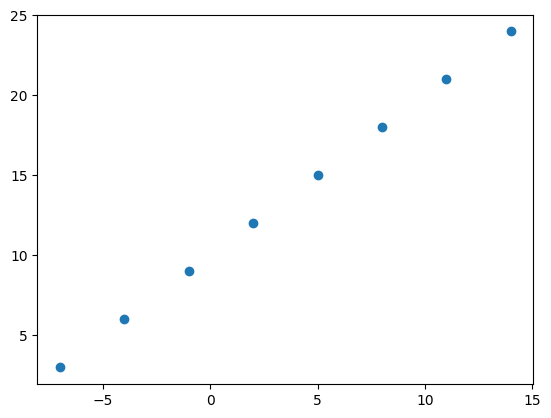

In [4]:
# creating a linear data for the linear regression model.
import numpy as np
import matplotlib.pyplot as plt

# create features.
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# create labels.
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y)

In [5]:
'''
# Regression input shapes and output shapes:
- One of the most important concepts when working with neural networks are the input and output shapes.

- The input shape is the shape of your data that goes into the model.
- The output shape is the shape of your data you want to come out of your model.
- These will differ depending on the problem you're working on.
- Neural networks accept numbers and output numbers. These numbers are typically represented as tensors (or arrays).
'''

# Example input and output shapes of a regression model
house_info = tf.constant(["bedroom", "bathroom", "garage"]) # X or input for neural networks.
house_price = tf.constant([939700])

house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [7]:
house_info.ndim # if someone tells to calculate the rank that means the number of dimension.

1

In [8]:
house_info.shape

TensorShape([3])

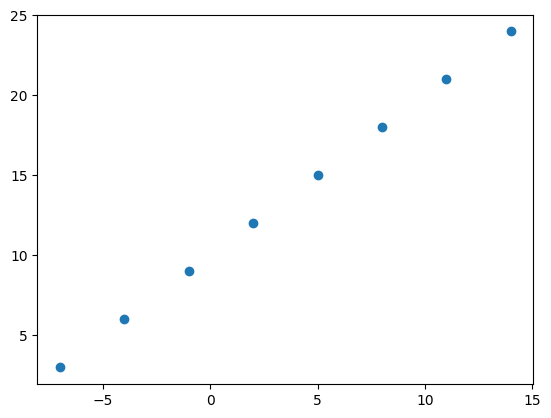

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create features (using tensors)
X = tf.constant([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels (using tensors)
y = tf.constant([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);

In [10]:
# Take a single example of X.
input_shape = X[0].shape

# Take a single example of y.
output_shape = y[0].shape

input_shape, output_shape # these both are scalars (no shape)

(TensorShape([]), TensorShape([]))

In [17]:
# Let's take a look at the single examples invidually.
X[0], y[0]

'''
In our case, we're trying to build a model to predict the pattern between X[0] equalling -7.0 and y[0] equalling 3.0. So, now we get our answer, we're trying to use 1 X value to predict 1 y value.
'''

"\nIn our case, we're trying to build a model to predict the pattern between X[0] equalling -7.0 and y[0] equalling 3.0. So, now we get our answer, we're trying to use 1 X value to predict 1 y value.\n"

### Steps in modelling with TensorFlow

In [ ]:
'''

# Steps in modelling with TensorFlow:

- In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

- * Creating a model - piece together the layers of a neural network yourself (using the Functional or Sequential API) or import a previously built model (known as transfer learning).

- * Compiling a model - defining how a models performance should be measured (loss/metrics) as well as defining how it should improve (optimizer).

- * Fitting a model - letting the model try to find patterns in the data (how does X get to y).

Note:-
# keras API to build an Neural Network.
# https://www.tensorflow.org/api_docs/python/tf/keras/Sequential
'''

In [18]:
'''
Note:- If you are using TensorFlow 2.7.0+, the `fit()` function no longer upscales input data to go from (batch_size, ) to (batch_size, 1). To fix this, we will need to expand the dimension of input data using `tf.expand_dims(input_data, axis=-1)`.

In our case, this means instead of
    - Using `model.fit(X, y, epochs=5),
    - Use `model.fit(tf.expand_dims(X, axis=-1), y, epochs=5)`.
'''

# set random seed.
tf.random.set_seed(42)

# Create a model using the Sequential API.
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile the model.
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mae']
)

# Fit the model.
# model.fit(X, y, epochs=5) # this will break with TensorFlow 2.7.0+
model.fit(tf.expand_dims(X, axis=-1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step - loss: 12.3742 - mae: 12.3742
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 12.2417 - mae: 12.2417
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 12.1092 - mae: 12.1092
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 11.9767 - mae: 11.9767
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 11.8442 - mae: 11.8442


In [19]:
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [21]:
# Make a prediction with the model.
model.predict([17.0])

ValueError: Unrecognized data type: x=[17.0] (of type <class 'list'>)

### Improving a model

In [ ]:
# To improve our model, we alter almost every part of the 3 steps we went through before.

    # 1. Creating a model - Adding more layers, increase number of hidden units (also called neurons) within each layer, change the activation function of each layer.
    # 2. Compiling a model - Choosing the better optimization function or changing the learning rate of the optimization function.
    # 3. Fitting a model - fitting the model for the more epochs or giving more data.

In [22]:
# set random seed.
tf.random.set_seed(42)

# Create a model using the Sequential API.
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# Compile the model.
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mae']
)

# Fit the model.
# model.fit(X, y, epochs=5) # this will break with TensorFlow 2.7.0+
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - loss: 10.1858 - mae: 10.1858
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 10.0533 - mae: 10.0533
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 9.9208 - mae: 9.9208
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 9.7883 - mae: 9.7883
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 9.6558 - mae: 9.6558
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 9.5233 - mae: 9.5233
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 9.3908 - mae: 9.3908
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 9.2583 - mae: 9.2583
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 9.1258 - mae: 9.1258
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 8.9933 - mae: 8.9933
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 8.8608 - mae: 8.8608
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 8.7283 - mae: 8.7283
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52m

In [23]:
# Remind ourselves of what X and y are
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [25]:
# Try and predict what y would be if X was 17.0
model.predict([17.0]) # the right answer is 27.0 (y = X + 10)

TypeError: Only integers, slices (`:`), ellipsis (`...`), tf.newaxis (`None`) and scalar tf.int32/tf.int64 tensors are valid indices, got 17.0

### Evaluating a model

In [27]:
# Workflow when building neural network is.
# Build a model -> Evaluate it -> Build (tweak) a model -> Evaluate it -> Build (tweak) a model -> Evaluate it -> ........


# Visualize, Visualize & Visualize : When it comes to evaluation.
'''
- The data - what data are you working with? What does it look like ?
- The model itself - what does the architecture look like? What are the different shapes ?
- The training of a model - how does a model perform while it learns ?
- The predictions of a model - how do the predictions of a model line up against the ground truth (the original labels) ?
'''

# Make a bigger dataset.
X = np.arange(-100, 100, 4)
X

array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])

In [28]:
# Make labels for the dataset (adhering to the same pattern as before)
y = np.arange(-90, 110, 4)
y

array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

In [29]:
# same result as above.
y = X + 10
y

array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

### Split data into training/test set

In [ ]:
'''
# This is the most important steps in the machine learning i.e.., Creating a training and test set (and when required, a validation set).

    - Training set - the model learns from this data, which is typically 70-80% of the total data available (like the course materials you study during the semester).

    - Validation set - the model gets tuned on this data, which is typically 10-15% of the total data available (like the practice exam you take before the final exam).

    - Test set - the model gets evaluated on this data to test what it has learned, it's typically 10-15% of the total data available (like the final exam you take at the end of the semester).

🔑 Note: When dealing with real-world data, this step is typically done right at the start of a project (the test set should always be kept separate from all other data). We want our model to learn on training data and then evaluate it on test data to get an indication of how well it generalizes to unseen examples.
'''

In [30]:
# Check how many samples we have.
len(X)

50

In [33]:
# Split data into train and test sets.
X_train = X[:40] # first 40 examples (80% of data)
y_train = y[:40]

X_test = X[40:] # last 10 examples (20% of data)
y_test = y[40:]

print("Training Data: ")
print(len(X_train), len(X_test))

Training Data: 
40 10


### Visualizing the data

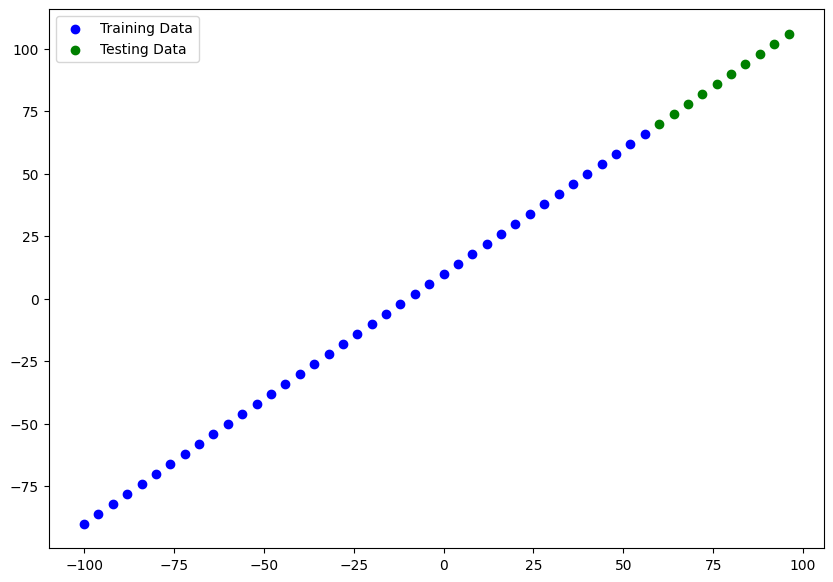

In [35]:
plt.figure(figsize=(10, 7))

# Plot training data in blue.
plt.scatter(X_train, y_train, c="b", label="Training Data")

# Plot test data in green.
plt.scatter(X_test, y_test, c="g", label="Testing Data")

# Show the legend.
plt.legend()

#
plt.show()

With this graph in mind, what we'll be trying to do is build a model which learns the pattern in the blue dots (X_train) to draw the green dots (X_test).

In [38]:
# set random seed.
tf.random.set_seed(42)

# Create a model (same as above)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # defining the input shape to our model.
])

# Compile model (same as above).
model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

# Fit the model (same as above).
# model.fit(X_train, y_train, epochs=100)
# model.fit(tf.expand_dims(X_train, axis=-1), y, epochs=50)

In [39]:
# This will work after specifying the input shape.
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

---
**Observation:-**

Calling `summary()` on our model shows us the layers it contains, the output shape and the number of parameters as above.


*   **Total params** - total number of parameters in the model.
*   **Trainable parameters** - these are the parameters (patterns) the model can update as it trains.
*   **Non-trainable parameters** - these parameters aren't updated during training (this is typical when you bring in the already learned patterns from other models during transfer learning).
*   Check this Links for [Intro to Deep Learning by MIT](https://www.youtube.com/watch?v=njKP3FqW3Sk)
---


In [40]:
# Fit the model to the training data.
model.fit(X_train, y_train, epochs=100, verbose=0) # verbose controls how much gets output.

In [41]:
# Check the model summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

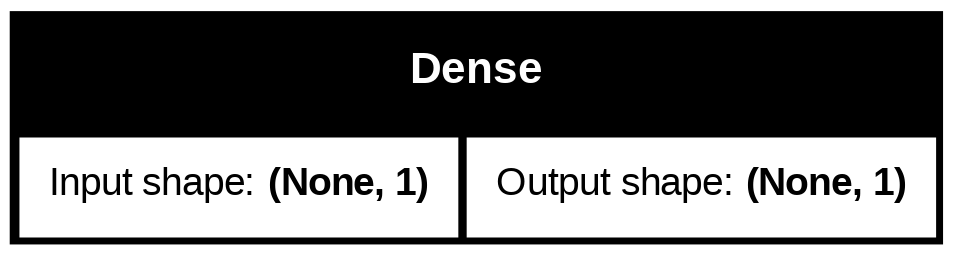

In [42]:
# In order to view the model in 2D plot implements the `plot_model()`.

from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes=True)

### Visualizing the predictions

In [44]:
# To visualize predictions, it's always a good idea to plot them against the ground truth labels.

# Often you'll see this in the form of y_test vs. y_pred (ground truth vs. predictions).

# First, we'll make some predictions on the test data (X_test), remember the model has never seen the test data.

# Make predictions.
y_preds = model.predict(X_test)

# View the predictions.
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([[ 63.26669 ],
       [ 67.38993 ],
       [ 71.51317 ],
       [ 75.636406],
       [ 79.75964 ],
       [ 83.88288 ],
       [ 88.00612 ],
       [ 92.12936 ],
       [ 96.252594],
       [100.37583 ]], dtype=float32)

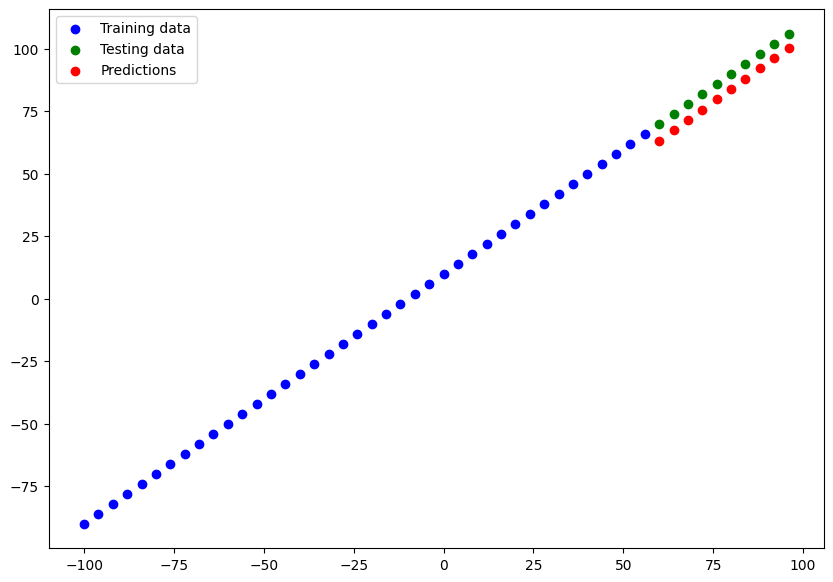

In [47]:
# It is a good idea to funationize everything so that we can use it later.
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_preds):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();

plot_predictions(train_data=X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test,
                 predictions=y_preds)


### Evaluating predictions

Alongisde visualizations, evaulation metrics are the alternative best option for evaluating our model.

Two of the main metrics used for regression problems are:


*   **Mean absolute error (MAE)** - the mean difference between each of the predictions.
*   **Mean squared error (MSE)** - the squared mean difference between of the
predictions (use if larger errors are more detrimental than smaller errors).


The lower each of these values, the better.

We can also use `model.evaluate()` which will return the loss of the model as well as any metrics setup during the compile step.



In [48]:
# Evaluate the model on the test set
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 6.1787 - mae: 6.1787


[6.178738117218018, 6.178738117218018]

In [51]:
# Calculate the mean absolute error
mae = tf.metrics.mae(y_true=y_test,
                                     y_pred=y_preds)
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([6.7333107, 6.6100693, 6.4868317, 6.363594 , 6.2403564, 6.117119 ,
       5.993881 , 5.8706436, 5.747406 , 5.6241684], dtype=float32)>

**Observation:**

 MAE should be a single output. Instead, we get 10 values. This is because our `y_test` and `y_preds` tensors are different shapes.

In [52]:
# Check the test label tensor values.
y_test

array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])

In [53]:
# Check the predictions tensor values (notice the extra square brackets)
y_preds

array([[ 63.26669 ],
       [ 67.38993 ],
       [ 71.51317 ],
       [ 75.636406],
       [ 79.75964 ],
       [ 83.88288 ],
       [ 88.00612 ],
       [ 92.12936 ],
       [ 96.252594],
       [100.37583 ]], dtype=float32)

Since, we have already discussed dealing with different input and output shapes is one of the most common issues we will face.

we can fix it using `squeeze()` -> it will remove the `1` dimension from our `y_preds` tensor, making it the same shape as `y_test`.

Note:- If we are comparing two tensors, it's important to make sure they are the right shapes.

In [54]:
# Shape before squeeze().
y_preds.shape

(10, 1)

In [55]:
# Shape after squeeze().
y_preds.squeeze().shape

(10,)

In [56]:
# Let's check once again.
y_test, y_preds.squeeze()

(array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106]),
 array([ 63.26669 ,  67.38993 ,  71.51317 ,  75.636406,  79.75964 ,
         83.88288 ,  88.00612 ,  92.12936 ,  96.252594, 100.37583 ],
       dtype=float32))

Now, they `y_test` & `y_preds` are on the same shape, Let's use our evalaution metrics.

In [57]:
# Calculate the MAE.
mae = tf.keras.metrics.mae(y_true=y_test,
                           y_pred=y_preds.squeeze()) # Implementing the squeeze to make in the same shape.

mae

<tf.Tensor: shape=(), dtype=float32, numpy=6.178738117218018>

In [60]:
# Calculate the MSE.
mse = tf.keras.metrics.mse(y_true=y_test,
                           y_pred=y_preds.squeeze())

mse

<tf.Tensor: shape=(), dtype=float32, numpy=38.302101135253906>

In [61]:
# Note, we can also calcualte the MAE using pure tensorflow functions.
tf.reduce_mean(
    tf.abs(y_test - y_preds.squeeze())
)

<tf.Tensor: shape=(), dtype=float64, numpy=6.178738021850586>

In [62]:
# Functionize the implemented loss functions.
def mae(y_test, y_pred):
    """
    Calculates the mean absolute error between y_test & y_preds.
    """
    return tf.keras.metrics.mae(y_test, y_pred)

def mse(y_test, y_pred):
    """
    Calculates the mean squared error between the y_test & y_preds.
    """
    return tf.keras.metrics.mse(y_test, y_pred)

### Running experiments to improve a model

To do so, we will build 3 models and compare their results:

1. `model_1` - same as original model, 1 layer, trained for 100 epochs.

2. `model_2` - 2 layers, trained for 100 epochs.

3. `model_3` - 2 layers, trained for 500 epochs.

**Build `model_1`**

In [63]:
# Set random seed
tf.random.set_seed(42)

# Replicate original model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_1.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 18.6736 - mae: 18.6736 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 10.8211 - mae: 10.8211
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 7.6685 - mae: 7.6685 
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 11.9919 - mae: 11.9919
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.1773 - mae: 8.1773
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.7214 - mae: 8.7214
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.5882 - mae: 8.5882
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 8.3555 - mae: 8.3555
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 9.0997 - mae: 9.0997
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.1700 - mae: 8.1700
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 8.8388 - mae: 8.8388
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 7.8893 - mae: 7.8893
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


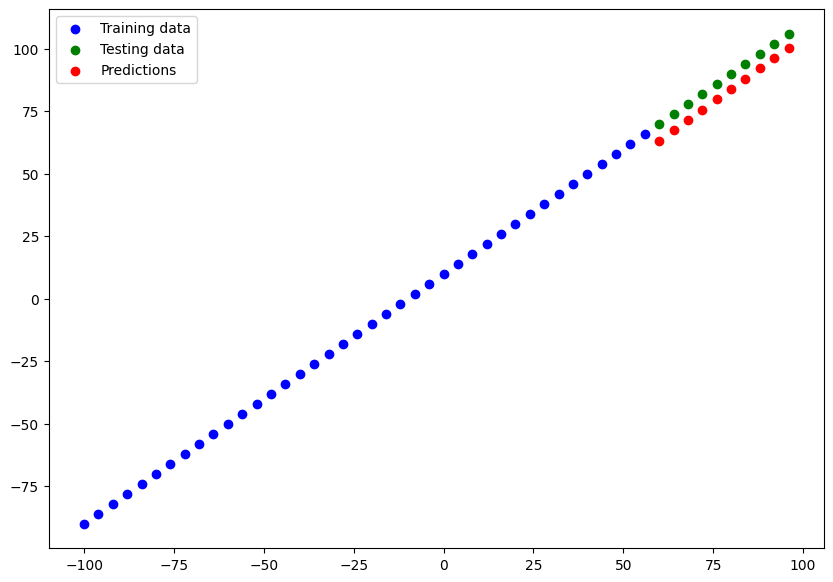

In [64]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(X_test)
plot_predictions(predictions=y_preds_1)

In [65]:
# Calculate model_1 metrics
mae_1 = mae(y_test, y_preds_1.squeeze()).numpy()
mse_1 = mse(y_test, y_preds_1.squeeze()).numpy()
mae_1, mse_1

(6.175304, 38.259315)

**Build `model_2`**

In [66]:
# set random seed.
tf.random.set_seed(42)

# Replicate model_1 and add an extra layer.
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1) # Adding a second layer.
])

# Compile the model.
model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

# Fit the model.
model_2.fit(
    tf.expand_dims(X_train, axis=-1),
    y_train,
    epochs=100,
    verbose=0 # set verbose to 0 for less output.
)

In [67]:
# Make and plot predictions for model_2.
y_preds_2 = model_2.predict(X_test)
y_preds_2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([[38.57856 ],
       [41.017464],
       [43.456364],
       [45.895267],
       [48.334167],
       [50.773067],
       [53.211975],
       [55.65087 ],
       [58.089775],
       [60.528675]], dtype=float32)

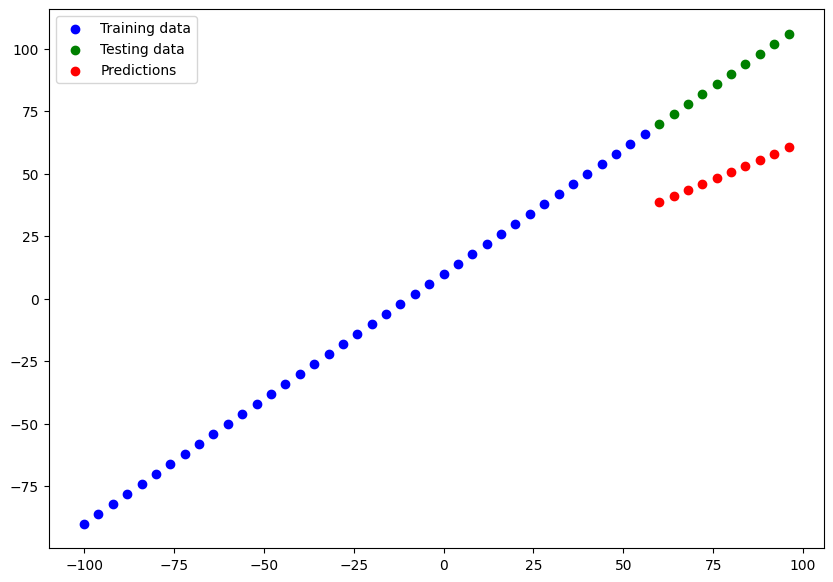

In [68]:
# plotting the prediction.
plot_predictions(predictions=y_preds_2)

In [69]:
# Calculate the model_2 metrics.
mae_2 = mae(y_test, y_preds_2.squeeze()).numpy()
mse_2 = mse(y_test, y_preds_2.squeeze()).numpy()
mae_2, mse_2

(38.44638, 1498.2297)

**Build `model_3`**

In [70]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_2
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model (this time for 500 epochs, not 100)
model_3.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0) # set verbose to 0 for less output

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


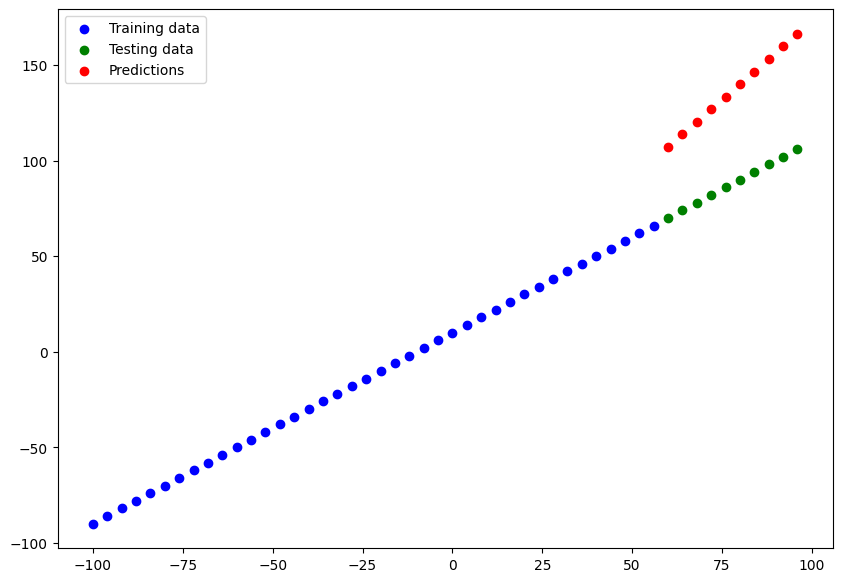

In [72]:
# Make and plot predictions for model_3
y_preds_3 = model_3.predict(X_test)
plot_predictions(predictions=y_preds_3)

In [73]:
# Calculate model_3 metrics
mae_3 = mae(y_test, y_preds_3.squeeze()).numpy()
mse_3 = mse(y_test, y_preds_3.squeeze()).numpy()
mae_3, mse_3

(48.756233, 2432.1187)

### Comparing results:

In [74]:
model_results = [
    ["model_1", mae_1, mse_1],
    ["model_2", mae_2, mse_2],
    ["model_3", mae_3, mae_3]
]

In [76]:
import pandas as pd
all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_1,6.175304,38.259315
1,model_2,38.446381,1498.229736
2,model_3,48.756233,48.756233


> 🔑 Note: One of our main goals should be to minimize the time between our experiments. The more experiments we do, the more things we'll figure out which don't work and in turn, get closer to figuring out what does work. Remember the machine learning practitioner's motto: "experiment, experiment, experiment".

### Tracking our experiments



*   [**TensorBoard**](https://www.tensorflow.org/tensorboard) - a component of the TensorFlow library to help track modelling experiments (we'll see this later).

*   [**Weights & Biases**](https://wandb.ai/site) - a tool for tracking all kinds of machine learning experiments (the good news for Weights & Biases is it plugs into TensorBoard)



### Saving a model

In [ ]:
# we can save a TensorFlow/Keras model using model.save()

# There are two ways to save a model in TensorFlow:
    # 1. The SavedModel Format (Default).
    # 2. The HDF5 Format.

# The main difference between the two is the SavedModel is automatically able to save custom objects (such as special layers) without additional modifications when loading the model back in.

In [83]:
# save a model using SavedModel format.
model_1.save("best_model_SavedModel_format.h5")

In [81]:
!ls best_model_SavedModel_format

ls: cannot access 'best_model_SavedModel_format': No such file or directory


In [82]:
# Save a model using the HDF5 format
model_2.save("best_model_HDF5_format.h5") # note the addition of '.h5' on the end


### Loading a model

In [85]:
# Load a model from the SavedModel format.
loaded_saved_model = tf.keras.models.load_model("/content/best_model_SavedModel_format.h5")
loaded_saved_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [86]:
# Compare model_2 with the SavedModel version (should return True)
model_2_preds = model_2.predict(X_test)

# Prediction with the save model.
saved_model_preds = loaded_saved_model.predict(X_test)

mae(y_test, saved_model_preds.squeeze()).numpy() == mae(y_test, model_2_preds.squeeze()).numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


False

In [87]:
# Load a model from the HDF5 format
loaded_h5_model = tf.keras.models.load_model("best_model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 1)                   │               2 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [88]:
# Compare model_2 with the loaded HDF5 version (should return True)
h5_model_preds = loaded_h5_model.predict(X_test)
mae(y_test, h5_model_preds.squeeze()).numpy() == mae(y_test, model_2_preds.squeeze()).numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


True

### Downloading a model (from Google Colab)

In [89]:
# Download the model (or any file) from Google Colab
from google.colab import files
files.download("best_model_HDF5_format.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Larger Example.

In [90]:
# Import required Libraries.
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

# Read in the insurance dataset.
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

# Checkout the insurance dataset.
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [91]:
# In the above dataset, we have a categorical feature such as region... so we have to convert the categorical features into the numerical with pandas `get_dummies()` function. because neural network can't handle the non-numerical inputs.

# Turn all categories into numbers.
insurance_one_hot = pd.get_dummies(insurance) # automatically handles the categories features.
insurance_one_hot.head() # view the converted columns.

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [92]:
# Split the dataset into the training and testing.
X = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]

In [93]:
# View features.
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [95]:
# Implementing the scikit learn train test split.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42) # set random state for reproducible splits

In [96]:
# Now, Let's build the Neural Networks with TensorFlow.
tf.random.set_seed(42)

# Building an Neural Networks.
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# Compile the model.
insurance_model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

# Fit the models.
insurance_model.fit(
    X_train,
    y_train,
    epochs=100
)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 10442.0811 - mae: 10442.0811
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7673.5527 - mae: 7673.5527
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7773.3345 - mae: 7773.3345
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7809.8501 - mae: 7809.8501
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7264.8931 - mae: 7264.8931
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7743.4375 - mae: 7743.4375
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7534.3301 - mae: 7534.3301
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7644.0625 - mae: 7644.0625
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7614.1406 - mae: 7614.1406
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7384.3623 - mae: 7384.3623
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7625.7632 - mae: 7625.7632
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

In [97]:
# Check the results of the insurance model.
insurance_model.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8077.3794 - mae: 8077.3794  


[8046.75537109375, 8046.75537109375]

From above result, we can figure out that, our model did not performs well. so Let's try to build an bigger models.

In [98]:
# Set random seed
tf.random.set_seed(42)

# Add an extra layer and increase number of units
insurance_model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), # 100 units
  tf.keras.layers.Dense(10), # 10 units
  tf.keras.layers.Dense(1) # 1 unit (important for output layer)
])

# Compile the model
insurance_model_2.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(), # Adam works but SGD doesn't
                          metrics=['mae'])

# Fit the model and save the history (we can plot this)
history = insurance_model_2.fit(X_train, y_train, epochs=100, verbose=0)

In [99]:
# Evaluate our larger model
insurance_model_2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4764.6699 - mae: 4764.6699  


[4636.08837890625, 4636.08837890625]

Note: For many problems, the Adam optimizer is a great starting choice. See Andrei Karpathy's "Adam is safe" point from A Recipe for Training Neural Networks for more.

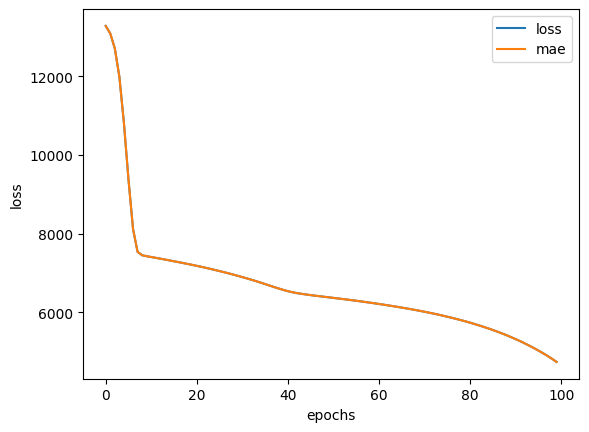

In [101]:
# Plot history (also known as a loss curve)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs");

---
From this, it looks like our model's loss (and MAE) were both still decreasing (in our case, MAE and loss are the same, hence the lines in the plot overlap eachother).

----
🤔 Question: How long should you train for?

It depends on what problem you're working on. Sometimes training won't take very long, other times it'll take longer than you expect. A common method is to set your model training for a very long time (e.g. 1000's of epochs) but set it up with an EarlyStopping callback so it stops automatically when it stops improving. We'll see this in another module.


---


In [102]:
# Try training for a little longer (100 more epochs)
history_2 = insurance_model_2.fit(X_train, y_train, epochs=100, verbose=0)

In [103]:
# Evaluate the model trained for 200 total epochs
insurance_model_2_loss, insurance_model_2_mae = insurance_model_2.evaluate(X_test, y_test)
insurance_model_2_loss, insurance_model_2_mae

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3464.9875 - mae: 3464.9875 


(3398.94091796875, 3398.94091796875)

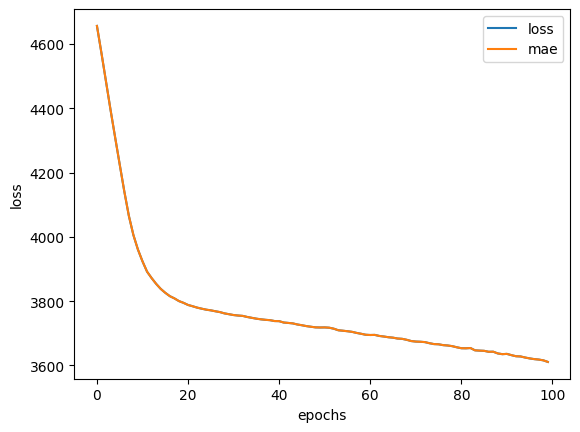

In [104]:
# Plot the model trained for 200 total epochs loss curves
pd.DataFrame(history_2.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs"); # note: epochs will only show 100 since we overrid the history variable

### Preprocessing data (normalization and standardization)



*   A common practice when working with neural networks is to make sure all of the data you pass to them is in the range 0 to 1. This practice is called normalization (scaling all values from their original range to, e.g. between 0 and 100,000 to be between 0 and 1).
*   There is another process call standardization which converts all of your data to unit variance and 0 mean.

These two practices are often part of a preprocessing pipeline (a series of functions to prepare your data for use with neural networks).


Knowing this, some of the major steps you'll take to preprocess your data for a neural network include:


*   Turning all of your data to numbers (a neural network can't handle strings).
*   Making sure your data is in the right shape (verifying input and output shapes).
*   Feature scaling:
    
    * Normalizing data (making sure all values are between 0 and 1). This is done by subtracting the minimum value then dividing by the maximum value minus the minimum. This is also referred to as min-max scaling.

    * Standardization (making sure all values have a mean of 0 and a variance of 1). This is done by subtracting the mean value from the target feature and then dividing it by the standard deviation.
    
    * Which one should you use?
    
        * With neural networks you'll tend to favour normalization as they tend to prefer values between 0 and 1 (you'll see this espcially with image processing), however, you'll often find a neural network can perform pretty well with minimal feature scaling.



In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

In [107]:
# Check out the data
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Now, just as before, we need to transform the non-numerical columns into numbers and this time we'll also be normalizing the numerical columns with different ranges (to make sure they're all between 0 and 1).

To do this, we're going to use a few classes from Scikit-Learn:

*   `make_column_transformer` - build a multi-step data preprocessing function for the folllowing transformations:
        
    * `MinMaxScaler` - make sure all numerical columns are normalized (between 0 and 1).
    
    * `OneHotEncoder` - one hot encode the non-numerical columns.

In [108]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# Create column transformer (this will help us normalize/preprocess our data)
ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]), # get all values between 0 and 1
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
)

# Create X & y
X = insurance.drop("charges", axis=1)
y = insurance["charges"]

# Build our train and test sets (use random state to ensure same split as before)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit column transformer on the training data only (doing so on test data would result in data leakage)
ct.fit(X_train)

# Transform training and test data with normalization (MinMaxScalar) and one hot encoding (OneHotEncoder)
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [109]:
# Non-normalized and non-one-hot encoded data example
X_train.loc[0]

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [110]:
# Normalized and one-hot encoded example
X_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [111]:
# Notice the normalized/one-hot encoded shape is larger because of the extra columns
X_train_normal.shape, X_train.shape

((1070, 11), (1070, 6))

In [112]:
# Set random seed
tf.random.set_seed(42)

# Build the model (3 layers, 100, 10, 1 units)
insurance_model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1)
])

# Compile the model
insurance_model_3.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=['mae'])

# Fit the model for 200 epochs (same as insurance_model_2)
insurance_model_3.fit(X_train_normal, y_train, epochs=200, verbose=0)

In [113]:
# Evaulate 3rd model
insurance_model_3_loss, insurance_model_3_mae = insurance_model_3.evaluate(X_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3213.7502 - mae: 3213.7502  


In [114]:
# Compare modelling results from non-normalized data and normalized data
insurance_model_2_mae, insurance_model_3_mae

(3398.94091796875, 3161.006103515625)

The main benefits of the `normalization`: `Faster Convergence time`.

[Neural Network Chapter 1](http://neuralnetworksanddeeplearning.com/chap1.html)